In [1]:
import numpy as np
import xarray as xr 
import pandas as pd
import glob
import os

import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend

from matplotlib.ticker import LogLocator, FuncFormatter

import sys
sys.path.append('../..//')
from utils_mitgcm import open_mitgcm_ds_from_config
from utils_signal_processing import *

# Load data and select ZZ

In [52]:
lake = 'zug'
model = f'{lake}_2025'
mitgcm_config, ds = open_mitgcm_ds_from_config('../../config.json', model)

In [53]:
folder_path = os.path.dirname(mitgcm_config['datapath'])
output_folder = os.path.join(folder_path, "seiche_analysis")
os.makedirs(output_folder, exist_ok=True)

In [54]:
grid_resolution = 100
ds['YC'] = np.arange(1, len(ds['YC'])+1) * grid_resolution - grid_resolution/2
ds['XC'] = np.arange(1, len(ds['XC'])+1) * grid_resolution - grid_resolution/2
ds['YG'] = np.arange(0, len(ds['YG'])) * grid_resolution
ds['XG'] = np.arange(0, len(ds['XG'])) * grid_resolution

In [55]:
omega = 7.2921e-5  # Earth's angular velocity (rad/s)
lat_rad = np.deg2rad(46.45)# Latitude of Lake Geneva (degrees)
f = 2 * omega * np.sin(lat_rad) # Coriolis parameter
f0 = abs(f/(2*np.pi)) # conversion from rad/s to 1/s

## Select sub XY for mean freq. Spectrum

In [56]:
start_date = np.datetime64('2025-04-01T00:00:00', 'ns')
end_date = np.datetime64('2025-12-01T00:00:00', 'ns')

In [48]:
zz = 0
xx1 = 2500 # Lucerne: 13700, Geneva: 49850, Neuchatel: 10000, Zug: 2500
yy1 = 4000 # Lucerne: 9100, Geneva: 18100, Neuchatel: 4000, Zug: 4000
xcells = 4
ycells = 4
xx2 = xx1+(grid_resolution*xcells)
yy2 = yy1+(grid_resolution*ycells)

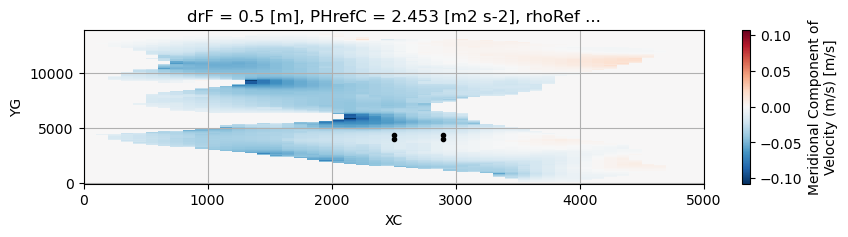

In [49]:
fig, ax = plt.subplots(1, figsize=(10, 2))
ds.VVEL.isel(time=24, Z=zz).plot()
plt.scatter(xx1,yy1, marker=".", color="k")
plt.scatter(xx1,yy2, marker = '.', color="k")
plt.scatter(xx2,yy1, marker=".", color="k")
plt.scatter(xx2,yy2, marker = '.', color="k")

plt.grid()

ds['THETA'].sel(XC=xx1, YC=yy1, method='nearest').to_netcdf(os.path.join(output_folder, 'theta_lexplore.nc'))

In [57]:
u = ds.UVEL.isel(Z=zz)\
          .sel(XG=slice(xx1,xx2), YC=slice(yy1,yy2))\
          .sel(time=slice(start_date, end_date))\
          .mean(['XG','YC'])\
          .load()

In [ ]:
v = ds.VVEL.isel(Z=zz)\
          .sel(XC=slice(xx1,xx2), YG=slice(yy1,yy2))\
          .sel(time=slice(start_date, end_date))\
          .mean(['XC','YG'])\
          .load()

w = ds.WVEL.isel(Zl=zz)\
          .sel(XC=slice(xx1,xx2), YC=slice(yy1,yy2))\
          .sel(time=slice(start_date, end_date))\
          .mean(['XC','YC'])\
          .load()

u = u.chunk({'time':-1})
v = v.chunk({'time':-1})
w = w.chunk({'time':-1})

u.load()
v.load()
w.load()

# Compute freq. spectrum

## Compute freq. spectrum

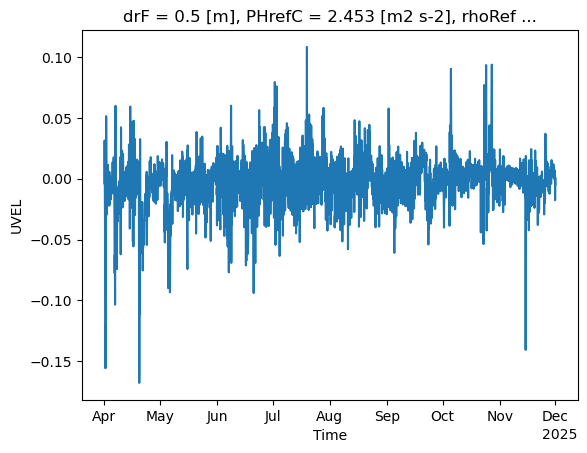

In [58]:
u.plot()

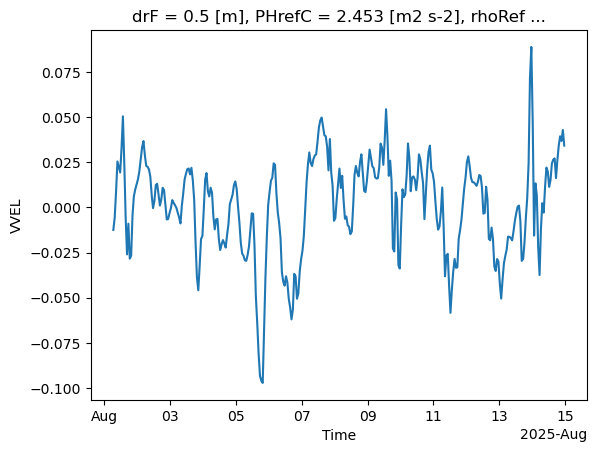

In [72]:
v.plot()

In [73]:
l_seg = int(len(u.time)/2)
u_fft = xr_compute_meanfft(u, seg_length=l_seg)
v_fft = xr_compute_meanfft(v, seg_length=l_seg)
w_fft = xr_compute_meanfft(w, seg_length=l_seg)

/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/python/horizontal_structure_analysis/seiches/filter/../../utils_signal_processing/fast_fourier_transform.py:79: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  amp_mean, err_up, err_low = xr.apply_ufunc(
/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/python/horizontal_structure_analysis/seiches/filter/../../utils_signal_processing/fast_fourier_transform.py:79: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  amp_mean, err_up, err_low = xr.apply_ufunc(
/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/python/horizontal_structure_analysis/seiches/filter/../../utils_signal_processing/fast_fourier_transform.py:79: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter

In [74]:
u_fft_mean = u_fft#.mean(dim=['XG','YC'])
v_fft_mean = v_fft#.mean(dim=['XC','YG'])
w_fft_mean = w_fft#.mean(dim=['XC','YC'])

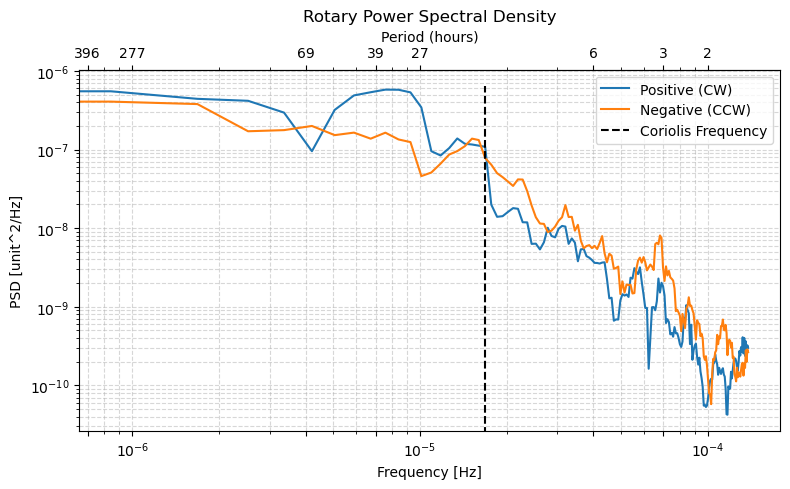

<Figure size 640x480 with 0 Axes>

In [75]:
freqs, Spp, Snn = rotary_psd(u, v, f0, dt=3600, NW=3, K=5)
plt.savefig(os.path.join(output_folder, 'rotary_spectrum.png'))

## Plot freq. spectrum

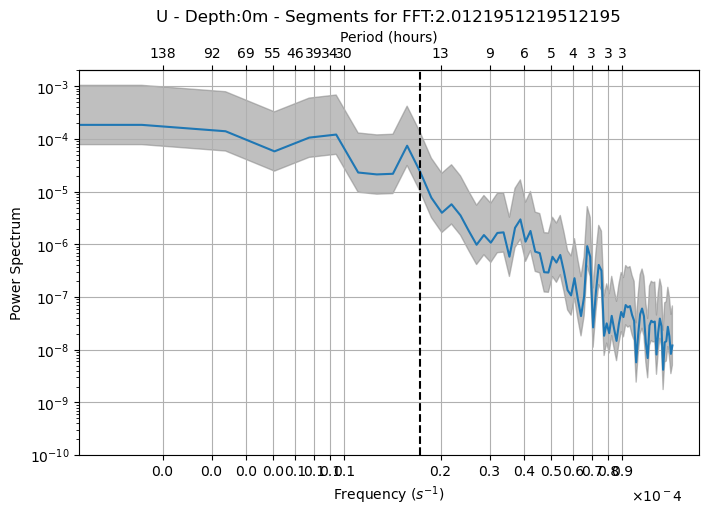

In [76]:
fig,ax = plot_freq_spectrum(u_fft_mean, 'U', depth=zz, l_segm=l_seg, y_lim_min=1e-10, x_lim_min=1e-6, fontsize=10)
ax.axvline(x = f0, linestyle="--", color="k",label="f0")
#fig.savefig(os.path.join(output_folder, 'freq_spectrum.png'))

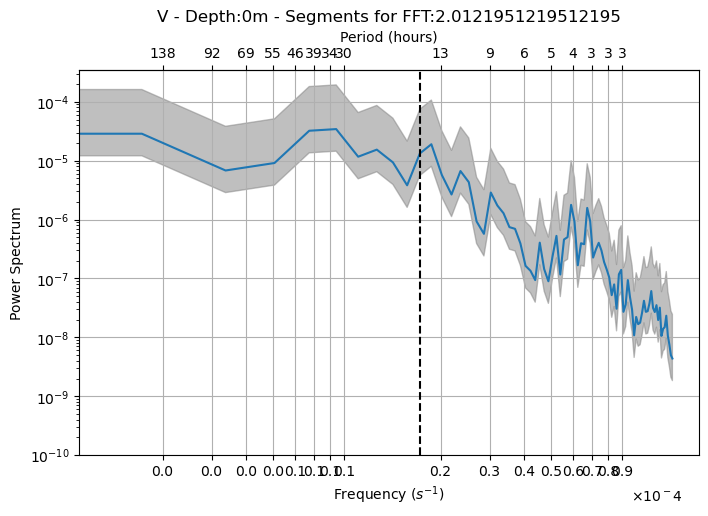

In [77]:
fig,ax = plot_freq_spectrum(v_fft_mean, 'V', depth=zz, l_segm=l_seg, y_lim_min=1e-10, x_lim_min=0.01e-4, fontsize=10)
ax.axvline(x = f0, linestyle="--", color="k",label="f0")

# Filtering in Spectral space  

## Defining cutoffs 
- Inertial period is at 16.4 hrs

In [18]:
cutoff1_hr = 50
cutoff2_hr = 30

cutoff1 = 1/(cutoff1_hr * 3600)
cutoff2 = 1/(cutoff2_hr * 3600)

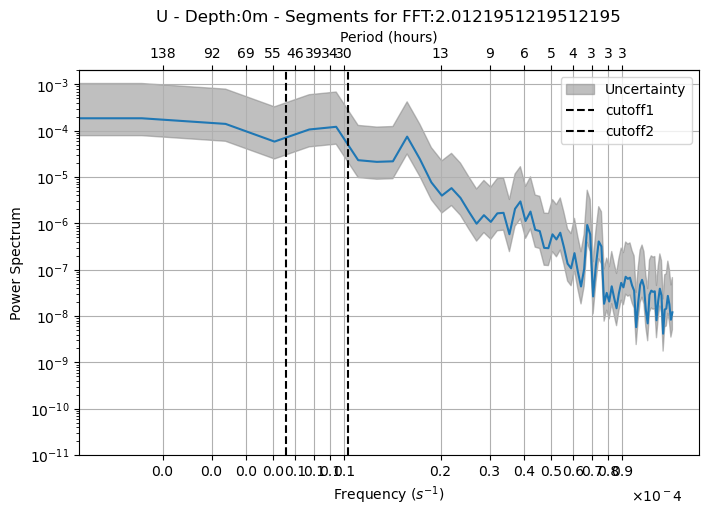

In [79]:
fig,ax = plot_freq_spectrum(u_fft_mean, 'U', depth=zz, l_segm=l_seg, y_lim_min=1e-11, x_lim_min=0.01e-4, fontsize=10)
ax.axvline(x = cutoff1, linestyle="--", color="k",label="cutoff1")
ax.axvline(x = cutoff2, linestyle="--", color="k",label="cutoff2")
ax.legend()
fig.savefig(os.path.join(output_folder, f'freq_spectrum_with_cutoffs_{cutoff2_hr}_{cutoff1_hr}h.png'))

In [80]:
path_cutoff_folder = os.path.join(output_folder, f'{cutoff2_hr}_{cutoff1_hr}h')
os.makedirs(path_cutoff_folder, exist_ok=True)

# Wavelet analysis

In [19]:
import pycwt as wavelet
np.int = int

In [59]:
signal = u.values
signal[np.isnan(signal)] = 0

# Remove mean (recommended)
signal = signal - np.nanmean(signal)

# Time step in seconds
dt = (
    u.time.diff("time")
    .astype("timedelta64[s]")
    .values[0]
    .astype(float)
)

# --------------------------------------------------------
# Wavelet parameters
# --------------------------------------------------------

mother = wavelet.Morlet(6)

# Smallest resolvable scale
s0 = 2 * dt

# Scale resolution (smaller -> finer)
dj = 1 / 12

# Number of scales
J = 100

# --------------------------------------------------------
# Continuous Wavelet Transform
# --------------------------------------------------------

wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(
    signal,
    dt,
    dj=dj,
    s0=s0,
    J=J,
    wavelet=mother,
)

# --------------------------------------------------------
# Power
# --------------------------------------------------------

power = np.abs(wave) ** 2

period = 1 / freqs      # seconds

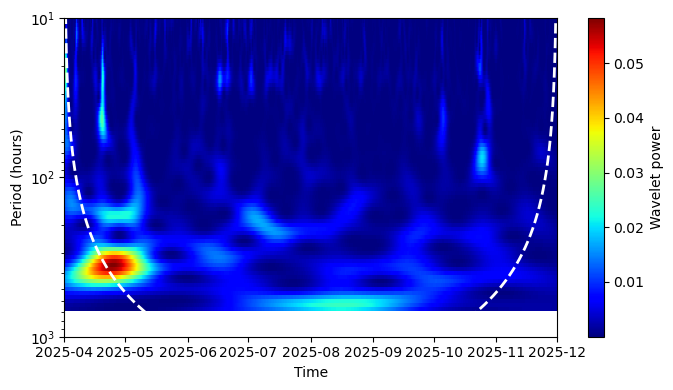

In [61]:
fig, ax = plt.subplots(figsize=(7,4))

pcm = ax.pcolormesh(
    u.time,
    period / 3600,          # hours
    power,
    shading="auto",
    cmap="jet",
)

ax.set_yscale("log")
ax.set_ylabel("Period (hours)")
ax.set_xlabel("Time")

cb = fig.colorbar(pcm)
cb.set_label("Wavelet power")

# Cone of influence
ax.plot(u.time, coi / 3600, "w--", lw=2)

#ax.axhline(y=cutoff1_hr, linestyle="--", c='white')
#ax.axhline(y=cutoff2_hr, linestyle="--", c='white')

ax.invert_yaxis()
ax.set_ylim(1000, 10)

plt.tight_layout()
plt.show()

## Low-pass filtering (slow motions)

### Filtering to low freq. motions

In [81]:
ulow = filter_signal_xarray(u, btype='lowpass', time_dim='time', dt=3600, period_cutoff_high=(cutoff1_hr*3600), order=5)
vlow = filter_signal_xarray(v, btype='lowpass', time_dim='time', dt=3600, period_cutoff_high=(cutoff1_hr*3600), order=5)
wlow = filter_signal_xarray(w, btype='lowpass', time_dim='time', dt=3600, period_cutoff_high=(cutoff1_hr*3600), order=5)

### Plotting low freq. motions 

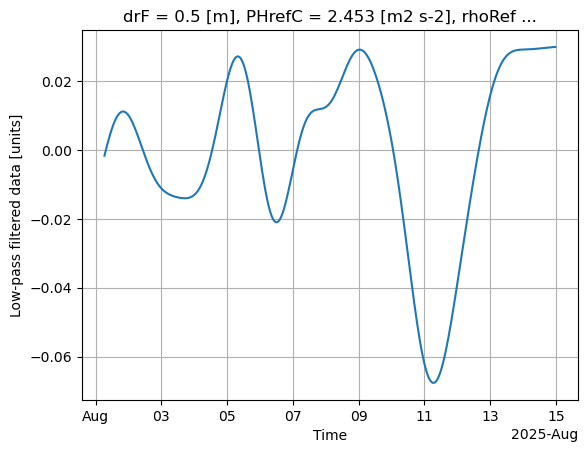

In [82]:
vmax_low = 7.5e-2
ulow.plot()
plt.grid()

## Bandpass filtering (seiches)

### Filtering to seiches

In [83]:
useiche = filter_signal_xarray(u, btype='bandpass', time_dim='time', dt=3600, period_cutoff_low=(cutoff1_hr*3600), period_cutoff_high=(cutoff2_hr*3600), order=5)
vseiche = filter_signal_xarray(v, btype='bandpass', time_dim='time', dt=3600, period_cutoff_low=(cutoff1_hr*3600), period_cutoff_high=(cutoff2_hr*3600), order=5)
wseiche = filter_signal_xarray(w, btype='bandpass', time_dim='time', dt=3600, period_cutoff_low=(cutoff1_hr*3600), period_cutoff_high=(cutoff2_hr*3600), order=5)

### Plotting seiches 

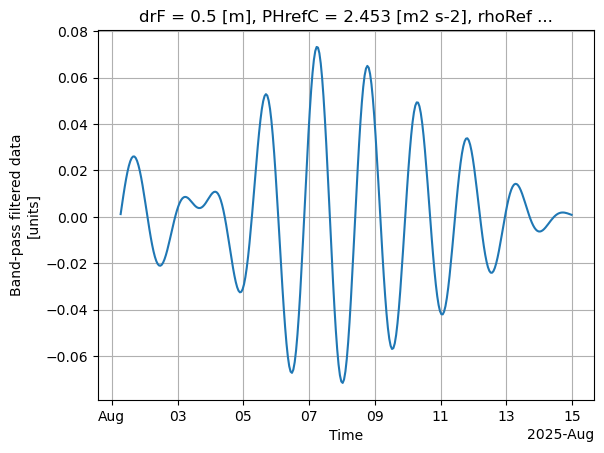

In [84]:
vmax_seiche = 7.5e-2
useiche.plot()
plt.grid()

## High-pass filtering (high frq. waves)

### Filtering to high freq. waves 

In [85]:
uhigh = filter_signal_xarray(u, btype='highpass', time_dim='time', dt=3600, period_cutoff_low=(cutoff2_hr*3600), order=5)
vhigh = filter_signal_xarray(v, btype='highpass', time_dim='time', dt=3600, period_cutoff_low=(cutoff2_hr*3600), order=5)
whigh = filter_signal_xarray(w, btype='highpass', time_dim='time', dt=3600, period_cutoff_low=(cutoff2_hr*3600), order=5)

### Plot high freq. internal waves

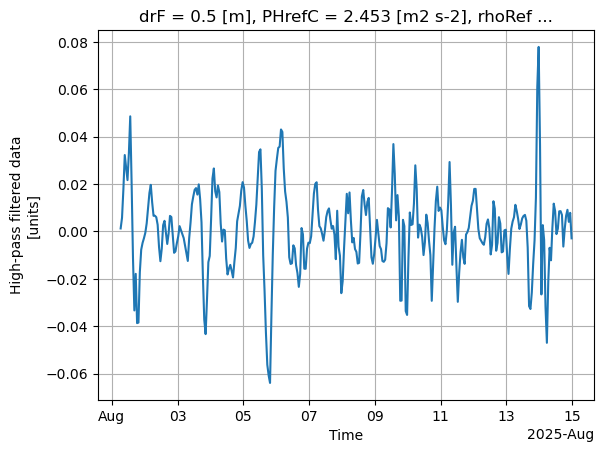

In [86]:
vmax_high = 7.5e-3
vhigh.plot()
plt.grid()

## Comparing time series

In [87]:
def plot_comparison_timeseries(vel, low, seiche, high, name_var):
    fig, ax = plt.subplots(2, 1, figsize=(18, 8))

    # bottom plot
    vel.plot(ax=ax[1], label="Original")
    (low + seiche + high).plot( ax=ax[1], label="low freq + seiche + high freq")

    # upper plot
    low.plot(ax=ax[0], label="low freq.")
    seiche.plot(ax=ax[0], label="seiche")
    high.plot(ax=ax[0], label="high freq.")

    for ax_i in (ax[1], ax[0]):
        ax_i.grid()
        ax_i.set_xlabel('')
        ax_i.set_title('')
        ax_i.legend(loc='upper right')
        ax_i.set_ylabel(f'{name_var} (m/s)')

    return fig, ax


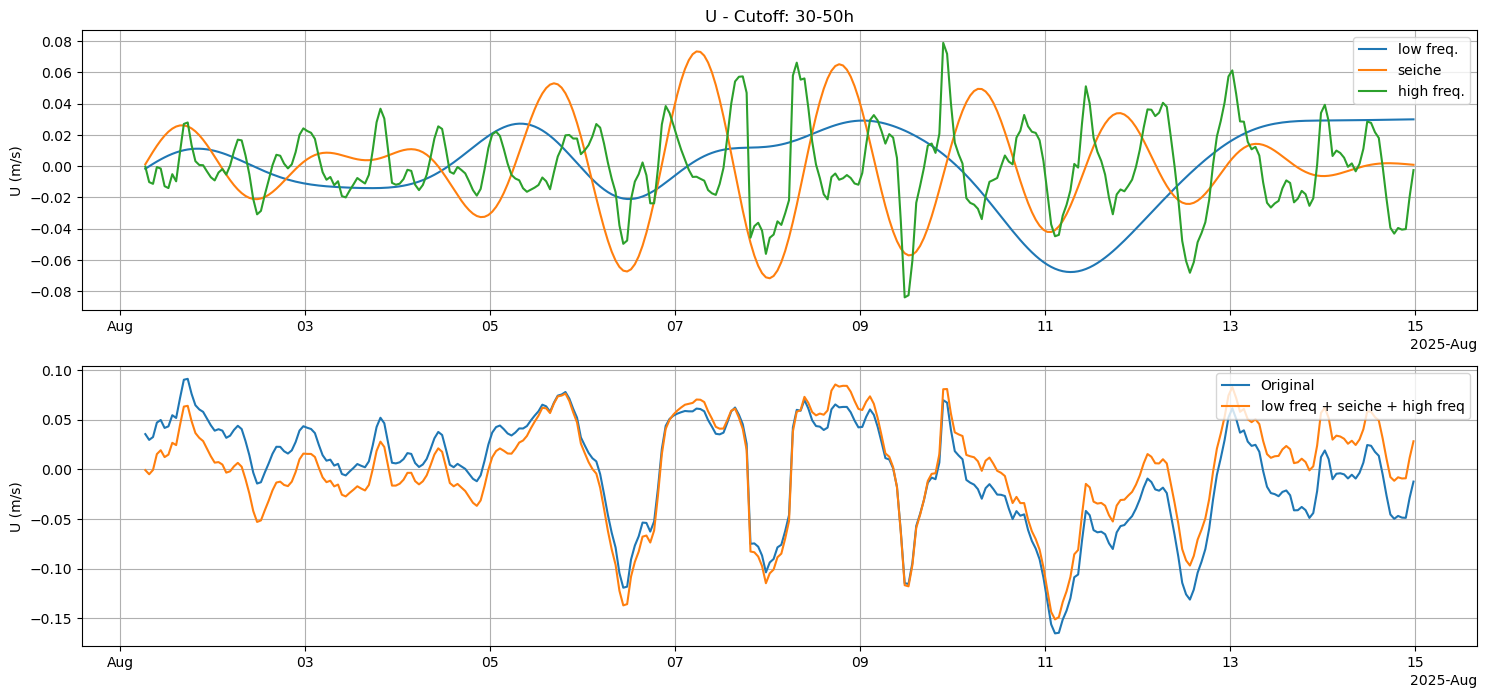

In [88]:
fig, ax = plot_comparison_timeseries(u, ulow, useiche, uhigh, 'U')
ax[0].set_title(f'U - Cutoff: {cutoff2_hr}-{cutoff1_hr}h')
plt.savefig(os.path.join(path_cutoff_folder, f'plot_filtered_timeseries_{cutoff2_hr}-{cutoff1_hr}h_U.png'))

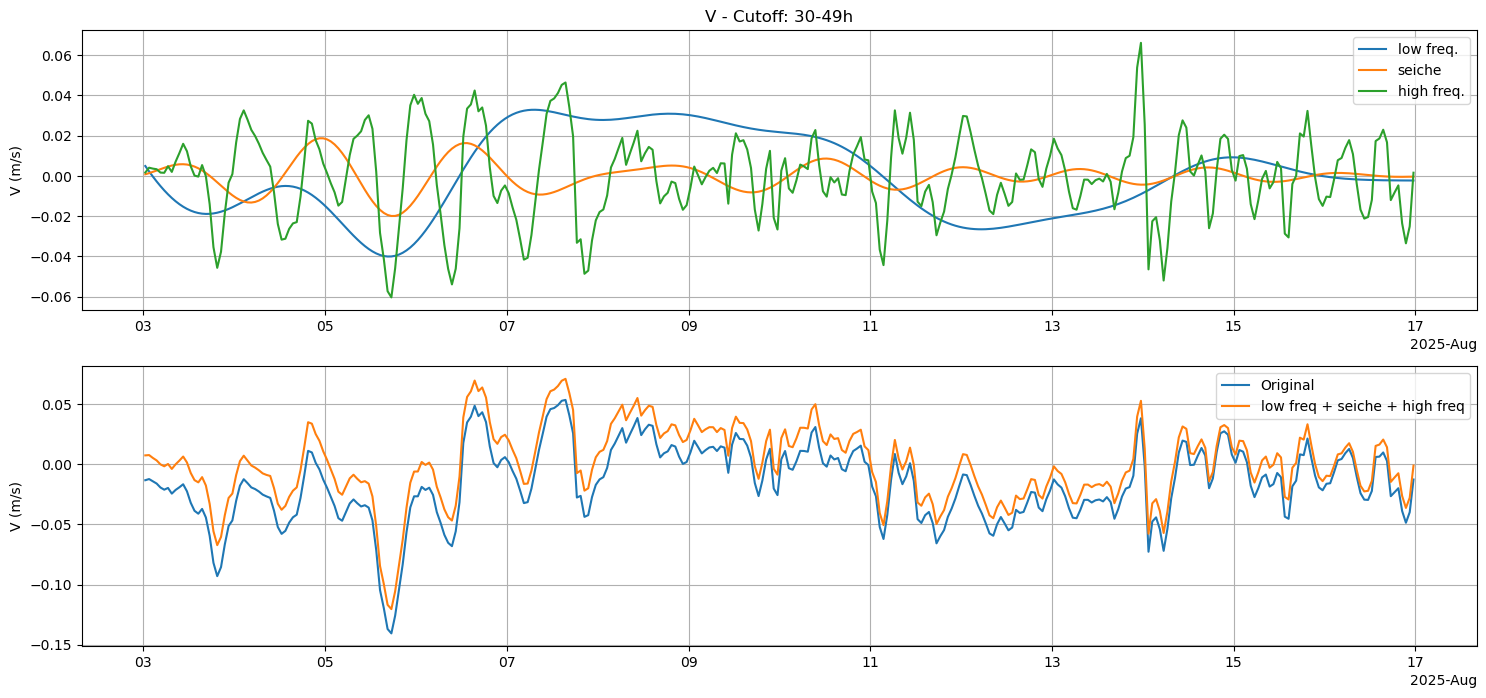

In [31]:
fig, ax = plot_comparison_timeseries(v, vlow, vseiche, vhigh, 'V')
ax[0].set_title(f'V - Cutoff: {cutoff2_hr}-{cutoff1_hr}h')
plt.savefig(os.path.join(path_cutoff_folder, f'plot_filtered_timeseries_{cutoff2_hr}-{cutoff1_hr}h_V.png'))

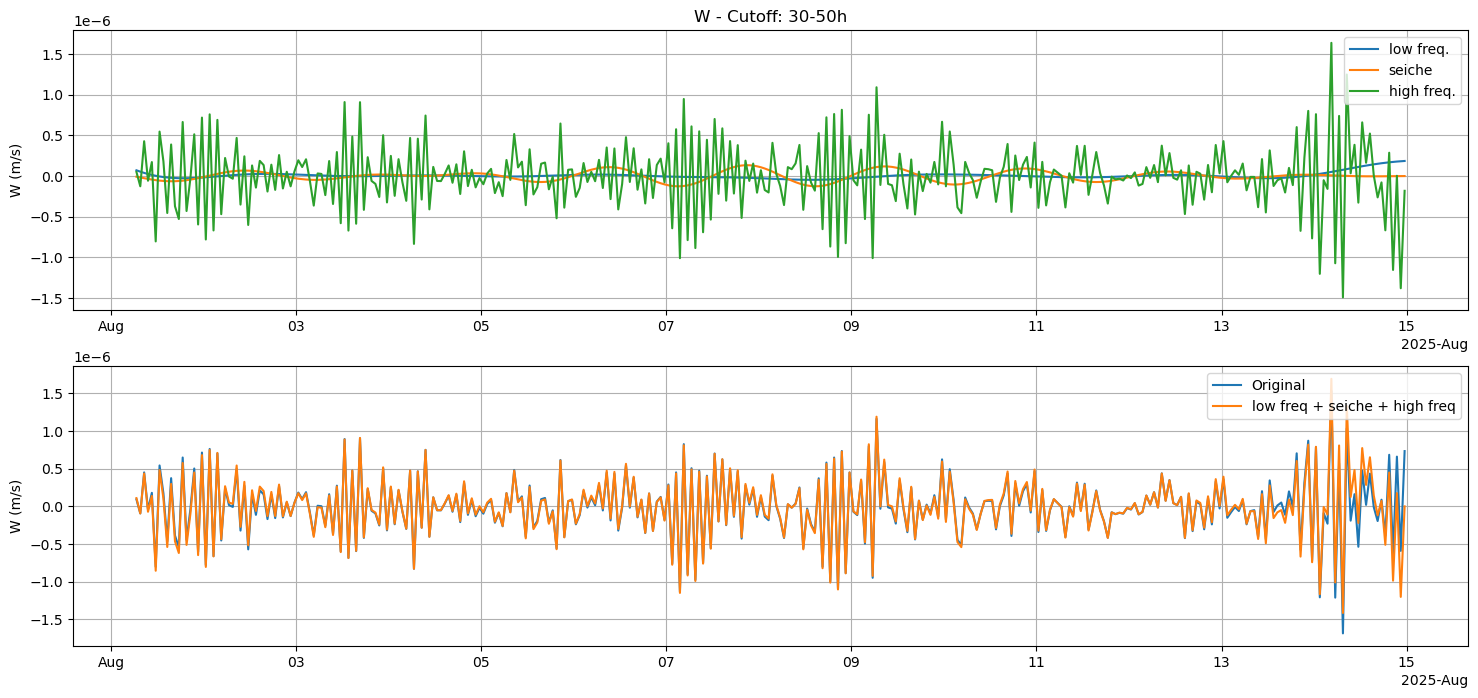

In [49]:
fig, ax = plot_comparison_timeseries(w, wlow, wseiche, whigh, 'W')
ax[0].set_title(f'W - Cutoff: {cutoff2_hr}-{cutoff1_hr}h')
plt.savefig(os.path.join(path_cutoff_folder, f'plot_filtered_timeseries_{cutoff2_hr}-{cutoff1_hr}h_W.png'))

In [50]:
from utils_plot import plot_colors

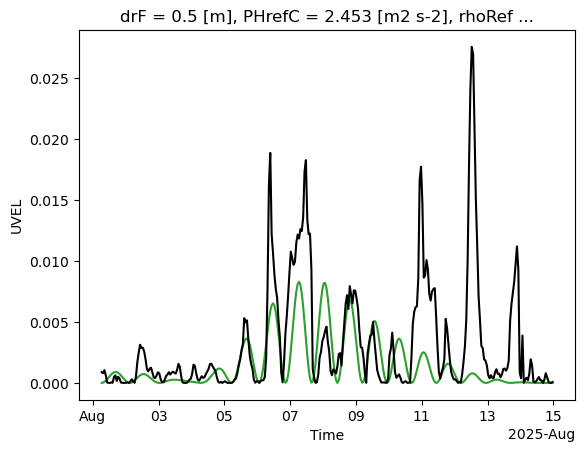

In [51]:
(useiche**2).plot(c=plot_colors.iw_color)
(u**2).plot(c=plot_colors.ke_color)